[-1.09457121 -1.1161631  -0.53816044 -0.20384865  0.05497888]
[-1.09457121 -2.21073431 -2.74889476 -2.95274341 -2.89776453]


(-15.0, 20.0)

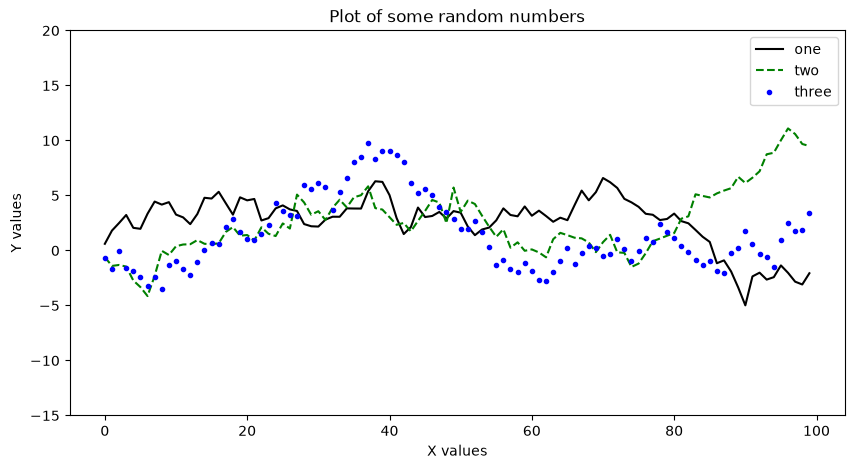

In [19]:
from numpy.random import randn
from matplotlib import pyplot as plt

fig = plt.figure(figsize=(10,5)) 
ax = fig.add_subplot(1, 1, 1)
# ax1 = fig.add_subplot(2, 2, 1)

# ax1.plot(randn(100).cumsum(), label = 'two')
# ax1.set_ylabel('Y values')

ax.plot(randn(100).cumsum(), 'k', label='one')
h = randn(5)
print(h)
print(h.cumsum()) #cumulative sum
ax.plot(randn(100).cumsum(), 'g--', label='two')
ax.plot(randn(100).cumsum(), 'b.', label='three')
ax.legend(loc='best')
ax.set_title('Plot of some random numbers')
ax.set_xlabel('X values')
ax.set_ylabel('Y values')
ax.set_ylim([-15, 20])

Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline'],
      dtype='str')


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


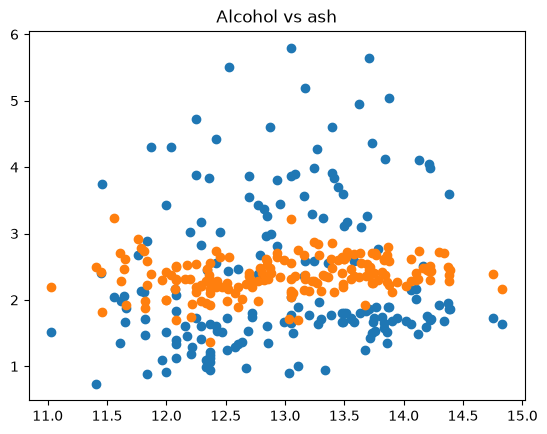

In [20]:
from sklearn.datasets import load_wine
import pandas as pd

wine = load_wine()
# print(wine)

df = pd.DataFrame(wine.data)
df.columns = wine.feature_names
print(df.columns)

df.head()

plt.scatter(df.alcohol, df.malic_acid)
plt.title("Alcohol vs malic acid")

plt.scatter(df.alcohol, df.ash) #confused on why the scatter plot comes that way
plt.title("Alcohol vs ash")

df


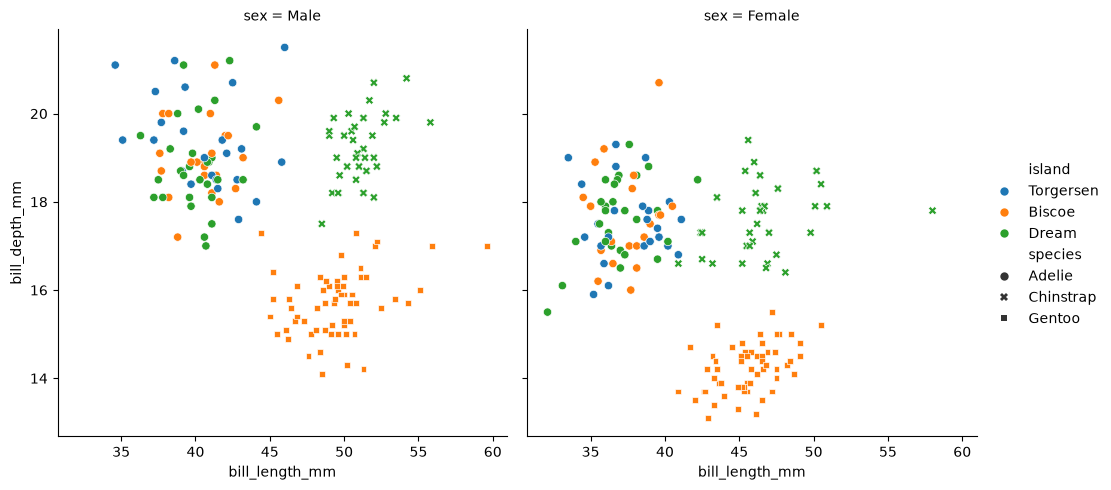

In [ ]:
import seaborn as sns

penguins = sns.load_dataset('penguins') #seaborn dataset
# print(penguins)

# plot seaborn dataset
sns.relplot(
    data=penguins,
    x="bill_length_mm", y="bill_depth_mm", col="sex",
    hue="island", style="species"
)

penguins1 = penguins.drop(['species', 'island', 'sex'], axis = 1)
#Heatmaps
# sns.heatmap(penguins1.corr(), annot=True)

r2 = 0.5005949903297372
rmse =  0.4544631604647202


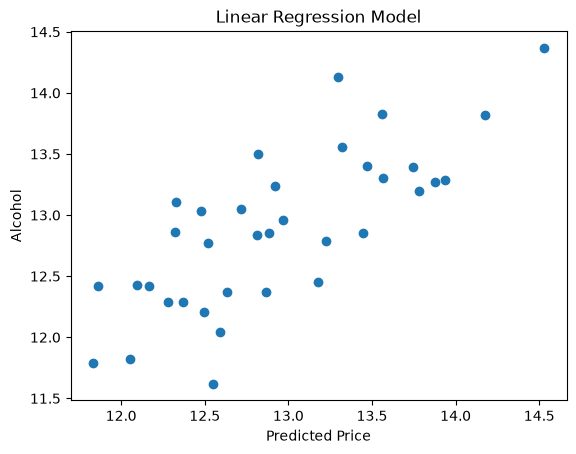

,Feature,Coefficients
0,malic_acid,0.14506804680233845
1,ash,0.08547579914191566
2,alcalinity_of_ash,-0.04179183870886317
3,magnesium,-0.0017926674390367973
4,total_phenols,0.11662580129771746
5,flavanoids,-0.07376390139762996
6,nonflavanoid_phenols,-0.20410394583832817
7,proanthocyanins,-0.18595321318710148
8,color_intensity,0.16913791237454295
9,hue,0.29200894708616654


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

response = df['alcohol']
features = df.drop('alcohol', axis = 1)

#split
X_train, X_test, y_train, y_test = train_test_split(features,response,test_size = 0.2, random_state = 8)
model = LinearRegression()
model.fit(X_train, y_train)
model.predict(X_test)

#r2
r2 = model.score(X_test, y_test)
print('r2 =',r2)

#rmse
rmse = mean_squared_error(y_test, model.predict(X_test))
print('rmse = ',rmse**0.5)

#plot
plt.scatter(model.predict(X_test), y_test)
plt.xlabel('Predicted Price')
plt.ylabel('Alcohol')
plt.title('Linear Regression Model')
plt.show()

# the coefficient list
feat = list(X_train.columns)
coef = model.coef_.transpose()
coef_table = np.vstack((feat, coef)).T
df = pd.DataFrame(coef_table, columns=['Feature', 'Coefficients'])
df

In [53]:
from sklearn.linear_model import Ridge, Lasso

#generate alphas to get a braod range
alphas = np.logspace(-2,5,10) # use logspace instead of 10**linspace
# print(alphas)

rmse_list = []
r2_list = []
for a in alphas:
    #call the object and train the model to get the best alpha
    ridge = Ridge(alpha = a, max_iter=1000)
    ridge.fit(X_train,y_train)
    pred = ridge.predict(X_test)

    r2 = ridge.score(X_test,y_test)
    r2_list.append(r2)
    rmse = mean_squared_error(y_test, pred)**0.5
    rmse_list.append(rmse)

ridge_result = np.vstack((alphas,r2_list,rmse_list)).T
ridge_df = pd.DataFrame(ridge_result, columns=['Alpha', 'R2', "RMSE"])
# print(ridge_df)

#Train the model after finding the lowest alpha
ridge = Ridge(alpha = 0.01, max_iter=1000)
ridge.fit(X_train,y_train)
pred = ridge.predict(X_test)
print(pd.Series(ridge.coef_, index = features.columns)) # Print coefficients





malic_acid                      0.144985
ash                             0.085157
alcalinity_of_ash              -0.041783
magnesium                      -0.001790
total_phenols                   0.116502
flavanoids                     -0.073465
nonflavanoid_phenols           -0.202076
proanthocyanins                -0.185933
color_intensity                 0.169065
hue                             0.290731
od280/od315_of_diluted_wines    0.247761
proline                         0.001150
dtype: float64


In [52]:
rmse_list = []
r2_list = []
for a in alphas:
    lasso = Lasso(alpha=a,max_iter=1000)
    lasso.fit(X_train,y_train)
    pred = lasso.predict(X_test)

    r2 = lasso.score(X_train,y_train)
    r2_list.append(r2)

    rmse = mean_squared_error(y_test,pred) ** 0.5
    rmse_list.append(rmse)

lasso_result = np.vstack((alphas, rmse_list, r2_list)).T
lasso_df = pd.DataFrame(lasso_result, columns=['Alpha', 'RMSE', "R2"])
lasso_df

#Train the model after finding the lowest alpha
lasso = Lasso(alpha = 0.01, max_iter=1000)
lasso.fit(X_train,y_train)
pred = lasso.predict(X_test)
print(pd.Series(lasso.coef_, index = features.columns)) # Print coefficients


malic_acid                      0.116123
ash                             0.000000
alcalinity_of_ash              -0.036417
magnesium                      -0.001378
total_phenols                   0.026218
flavanoids                      0.000000
nonflavanoid_phenols           -0.000000
proanthocyanins                -0.128780
color_intensity                 0.148435
hue                             0.000000
od280/od315_of_diluted_wines    0.192431
proline                         0.001263
dtype: float64
